# Fold-0 uncertainty comparison: **BayesNF** vs **LGBM**

End-to-end side-by-side evaluation on the canonical fold-0 holdout.

**Test set.** 394 stations defined by `bayesnf/data/bayesnf_fold0_test.parquet`
(= `fold == 0` of `lgbm/fold_assignment.parquet`). Both models are evaluated
on this exact station set.

**Caveat (read once, then forget).** The LGBM OOF parquet
(`lgbm/oof_predictions.parquet`, written by `lgbm_explain.ipynb` cell 7b)
only contains rows where `observed_mm ≥ 0.5` — those are the Stage-2
(amount-on-wet) audit predictions. There are no `datetime` columns and
no dry rows. Consequences:

- Direct **global** comparison (`All records` in `7_comparison.tex`) is
  not possible from these artifacts alone — that needs the fused
  Stage-1 ⊗ Stage-2 OOF, which is not currently persisted.
- We compare on the **observed-wet** slice (`y ≥ 0.5`). BayesNF is
  restricted to wet rows of its fold-0 test set; LGBM is used as-is.
- Time spans differ (BayesNF ≈ 10-year fit window, LGBM 1961–2023 OOF on
  the same stations). This is a confounder we acknowledge — when the
  thesis-protocol holdout is materialised (492 stations with consistent
  dates), this notebook will be re-pointed.

**What we compute.** Every diagnostic from
`notebooks/05_bayesnf/uncertainty/_compute_uncertainty.py` —
PIT + KS, reliability per quantile, sharpness, spread-skill, Hersbach
CRPS decomposition (`REL + CRPS_pot + Tail`), Brier decomposition for
the wet detector (where applicable), and conditional CRPS by intensity
bin. Each is reported for both models side by side.

## 1. Setup

In [1]:
import os, sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3

PROJECT_ROOT = Path('/Users/etomengoi/Desktop/precip_interpolation_thesis')
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks' / '05_bayesnf' / 'uncertainty'))
import _compute_uncertainty as bnf_unc

# Load .env so boto3 sees AWS credentials
env_file = PROJECT_ROOT / '.env'
if env_file.exists():
    for line in env_file.read_text().splitlines():
        if '=' in line and not line.startswith('#'):
            k, _, v = line.partition('=')
            os.environ.setdefault(k.strip(), v.strip())

S3_BUCKET     = 'thesis-data-ismaktam'
BNF_RUN       = 'vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5'
BNF_PREDS_KEY = f'bayesnf/runs/{BNF_RUN}/preds.parquet'
LGBM_OOF_KEY  = 'lgbm/oof_predictions.parquet'
BNF_TEST_KEY  = 'bayesnf/data/bayesnf_fold0_test.parquet'

CACHE = Path('/tmp/fold0_comparison')
CACHE.mkdir(parents=True, exist_ok=True)

QUANTILE_COLS   = bnf_unc.QUANTILE_COLS    # ['q05', ..., 'q95']
QUANTILE_LEVELS = bnf_unc.QUANTILE_LEVELS  # np.array([0.05, ..., 0.95])
WET_THRESHOLD   = bnf_unc.WET_THRESHOLD_MM  # 0.5

s3 = boto3.client('s3', region_name='eu-north-1')

def _download(key: str, local_name: str) -> Path:
    p = CACHE / local_name
    if not p.exists():
        print(f'[s3] downloading {key}  →  {p.name}')
        s3.download_file(S3_BUCKET, key, str(p))
    else:
        print(f'[cache] {p.name}')
    return p

def _bnf_preds_path() -> Path:
    # Prefer the local healthy preds.parquet; fall back to S3.
    # (The S3 copy of this run was corrupted to a 3.3 MB all-zero file.)
    local = PROJECT_ROOT / 'results' / 'bayesnf' / 'runs' / BNF_RUN / 'preds.parquet'
    if local.exists() and local.stat().st_size > 10 * 1024 * 1024:
        print(f'[local] {local}  ({local.stat().st_size/1024/1024:.1f} MB)')
        return local
    return _download(BNF_PREDS_KEY, 'bnf_preds.parquet')

## 2. Load fold-0 holdout stations and both prediction sets

In [2]:
# fold-0 test stations
test_path = _download(BNF_TEST_KEY, 'bnf_fold0_test.parquet')
fold0_sids = set(pd.read_parquet(test_path, columns=['station_id'])['station_id'].unique())
print(f'fold-0 holdout stations: {len(fold0_sids):,}')

# BayesNF (local-first, S3 fallback)
bnf_path = _bnf_preds_path()
bnf_full = pd.read_parquet(bnf_path)
bnf = bnf_full[bnf_full.station_id.isin(fold0_sids)].reset_index(drop=True)
print(f'\n[BayesNF preds]')
print(f'  total rows in run:      {len(bnf_full):>12,}')
print(f'  rows on fold-0 stations:{len(bnf):>12,}  ({bnf.station_id.nunique()} stations)')
print(f'  date range:             {bnf.datetime.min().date()} → {bnf.datetime.max().date()}')
print(f'  wet (y≥0.5):            {(bnf.observed_mm >= WET_THRESHOLD).sum():>12,}')
print(f'  dry (y<0.5):            {(bnf.observed_mm <  WET_THRESHOLD).sum():>12,}')

# LGBM
lgbm_path = _download(LGBM_OOF_KEY, 'lgbm_oof.parquet')
lgbm_full = pd.read_parquet(lgbm_path)
lgbm = lgbm_full[lgbm_full.station_id.isin(fold0_sids)].reset_index(drop=True)
print(f'\n[LGBM OOF]')
print(f'  total rows in OOF:      {len(lgbm_full):>12,}')
print(f'  rows on fold-0 stations:{len(lgbm):>12,}  ({lgbm.station_id.nunique()} stations)')
print(f'  fold_id values seen:    {sorted(lgbm.fold_id.unique().tolist())}')
print(f'  min(y), max(y):         {lgbm.observed_mm.min():.2f}, {lgbm.observed_mm.max():.1f}')
print(f'  frac y≥0.5:             {(lgbm.observed_mm >= WET_THRESHOLD).mean():.3f}   ← parquet pre-filtered to wet')

[cache] bnf_fold0_test.parquet


fold-0 holdout stations: 394
[local] /Users/etomengoi/Desktop/precip_interpolation_thesis/results/bayesnf/runs/vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5/preds.parquet  (19.7 MB)

[BayesNF preds]
  total rows in run:         1,438,888
  rows on fold-0 stations:   1,438,888  (394 stations)
  date range:             2013-01-01 → 2022-12-31
  wet (y≥0.5):                 531,016
  dry (y<0.5):                 907,872
[cache] lgbm_oof.parquet



[LGBM OOF]
  total rows in OOF:        17,406,454
  rows on fold-0 stations:   3,520,827  (394 stations)
  fold_id values seen:    [0]
  min(y), max(y):         0.50, 312.0
  frac y≥0.5:             1.000   ← parquet pre-filtered to wet


## 3. Build arrays on the observed-wet slice

The LGBM OOF parquet has no dry rows. To keep things apples-to-apples we
restrict the BayesNF subset to `observed_mm ≥ 0.5` as well. From this
point on every metric is computed on the **observed-wet slice**.

In [3]:
bnf_wet = bnf[bnf.observed_mm >= WET_THRESHOLD].reset_index(drop=True)
print(f'BayesNF wet rows: {len(bnf_wet):>10,}')
print(f'LGBM    wet rows: {len(lgbm):>10,}')
print(f'  (the row-count gap is the time-window asymmetry — see notebook header)')

def to_arrays(df):
    y  = df['observed_mm'].to_numpy(dtype=np.float64)
    mu = df['mean_mm'].to_numpy(dtype=np.float64)
    q  = np.sort(df[QUANTILE_COLS].to_numpy(dtype=np.float64), axis=1)
    return y, mu, q

y_bnf,  mu_bnf,  q_bnf  = to_arrays(bnf_wet)
y_lgbm, mu_lgbm, q_lgbm = to_arrays(lgbm)
print('\narrays ready')

BayesNF wet rows:    531,016
LGBM    wet rows:  3,520,827
  (the row-count gap is the time-window asymmetry — see notebook header)



arrays ready


## 4. Run every uncertainty block for both models

`block_pit`, `block_reliability`, `block_sharpness`, `block_spread_skill`,
`block_hersbach`, `block_conditional_crps` — all imported from
`notebooks/05_bayesnf/uncertainty/_compute_uncertainty.py`. Each is a pure
function of `(y, [mu,] q)` so it works identically for both models.

Brier decomposition for the wet detector is skipped here because the slice
is already wet-only (base rate ≈ 1, UNC ≈ 0 — see earlier discussion).

In [4]:
def compute_all(y, mu, q, label):
    t0 = time.time(); print(f'[{label}]')
    R = {}
    R['mae']  = float(np.abs(y - mu).mean())
    R['rmse'] = float(np.sqrt(((y - mu) ** 2).mean()))
    R['bias'] = float((mu - y).mean())
    R['pit']            = bnf_unc.block_pit(y, q);                print(f'  pit          ok')
    R['reliability']    = bnf_unc.block_reliability(y, q);        print(f'  reliability  ok')
    R['sharpness']      = bnf_unc.block_sharpness(q, y);          print(f'  sharpness    ok')
    R['spread_skill']   = bnf_unc.block_spread_skill(y, mu, q);   print(f'  spread_skill ok')
    hers, crps_row      = bnf_unc.block_hersbach(y, q);           print(f'  hersbach     ok')
    R['hersbach']       = hers
    R['_crps_row']      = crps_row
    R['conditional_crps'] = bnf_unc.block_conditional_crps(y, crps_row); print(f'  cond_crps    ok')
    print(f'  total: {time.time()-t0:.1f}s')
    return R

R_bnf  = compute_all(y_bnf,  mu_bnf,  q_bnf,  'BayesNF wet')
print()
R_lgbm = compute_all(y_lgbm, mu_lgbm, q_lgbm, 'LGBM wet')

[BayesNF wet]


  pit          ok
  reliability  ok


  sharpness    ok
  spread_skill ok
  hersbach     ok
  cond_crps    ok
  total: 1.3s

[LGBM wet]


  pit          ok


  reliability  ok


  sharpness    ok


  spread_skill ok


  hersbach     ok
  cond_crps    ok
  total: 8.3s


## 5. Headline comparison table

In [5]:
def headline(R):
    h     = R['hersbach']
    s_wet = R['sharpness']['wet']
    rel_w = R['reliability']['wet']
    pit_w = R['pit']['wet']
    return {
        'n_rows':                            len(R['_crps_row']),
        'MAE':                               round(R['mae'], 4),
        'RMSE':                              round(R['rmse'], 4),
        'Bias':                              round(R['bias'], 4),
        'CRPS':                              round(h['crps_per_row_mean'], 4),
        '  Reliability (Hersbach)':          round(h['reliability'], 4),
        '  CRPS_pot':                        round(h['crps_pot'], 4),
        '  Tail':                            round(h['tail_mean'], 4),
        'Per-quantile cov. RMS deviation':   round(rel_w['rms_deviation'], 4),
        'Per-quantile cov. max abs dev.':    round(rel_w['max_abs_deviation'], 4),
        'PIT KS-statistic (wet)':            round(pit_w['ks_statistic'], 4),
        'Sharpness q95-q05 (med, mm)':       round(s_wet['q95_minus_q05']['median'], 3),
        'Sharpness q90-q10 (med, mm)':       round(s_wet['q90_minus_q10']['median'], 3),
    }

tbl = pd.DataFrame({'BayesNF': headline(R_bnf), 'LGBM': headline(R_lgbm)})
tbl['Δ (LGBM − BNF)'] = (tbl['LGBM'] - tbl['BayesNF']).round(4)
tbl

,BayesNF,LGBM,Δ (LGBM − BNF)
n_rows,531016.0000,3.520827e+06,2.989811e+06
MAE,0.8022,1.066300e+00,2.641000e-01
RMSE,2.0738,2.164100e+00,9.030000e-02
Bias,-0.1251,-1.699000e-01,-4.480000e-02
CRPS,0.6827,8.101000e-01,1.274000e-01
Reliability (Hersbach),0.0602,8.400000e-03,-5.180000e-02
CRPS_pot,0.5418,6.728000e-01,1.310000e-01
Tail,0.0806,1.289000e-01,4.830000e-02
Per-quantile cov. RMS deviation,0.0937,1.050000e-02,-8.320000e-02
Per-quantile cov. max abs dev.,0.1663,1.910000e-02,-1.472000e-01


## 6. PIT histograms (calibration shape)

If a forecast is perfectly calibrated, PIT values are Uniform(0,1) and the
histogram is flat. A spike at 0 means the model is too often under-predicting
(observation falls below `q05` more often than 5 % of the time). A U-shape
means under-dispersion (intervals too narrow).

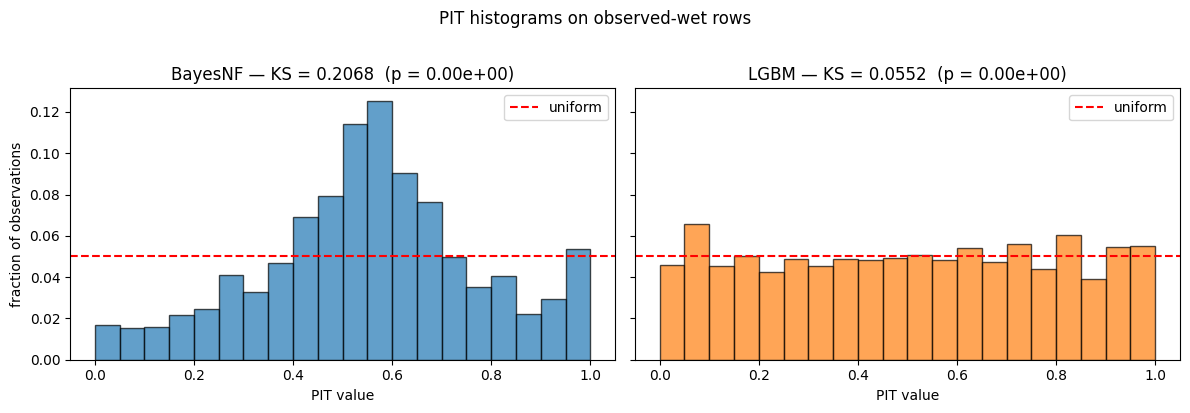

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a, (lbl, R) in zip(ax, [('BayesNF', R_bnf), ('LGBM', R_lgbm)]):
    pit_w  = R['pit']['wet']
    edges  = np.array(pit_w['histogram_edges'])
    counts = np.array(pit_w['histogram_counts']).astype(float)
    pmf    = counts / counts.sum()
    centers = 0.5 * (edges[:-1] + edges[1:])
    a.bar(centers, pmf, width=np.diff(edges), edgecolor='k', alpha=0.7,
          color='C0' if lbl == 'BayesNF' else 'C1')
    a.axhline(1.0 / len(counts), color='r', linestyle='--', label='uniform')
    a.set_title(f'{lbl} — KS = {pit_w["ks_statistic"]:.4f}  (p = {pit_w["ks_p_value"]:.2e})')
    a.set_xlabel('PIT value')
    a.legend()
ax[0].set_ylabel('fraction of observations')
plt.suptitle('PIT histograms on observed-wet rows', y=1.02)
plt.tight_layout(); plt.show()

## 7. Reliability per quantile

The 45° line is perfect calibration: for nominal level α the empirical
fraction `mean(y ≤ q_α)` should equal α. LGBM is expected to track the line
tightly (pinball-loss optimises exactly this). BayesNF, fitting a joint
likelihood instead, may bow off the line.

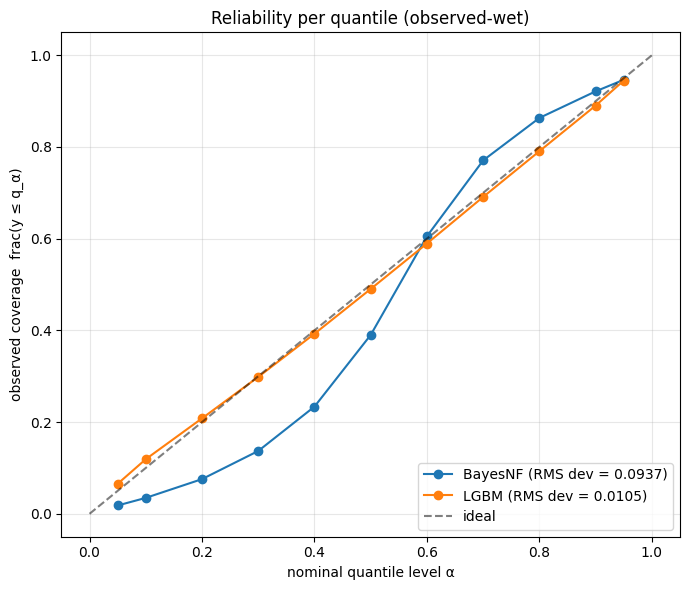

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
for lbl, R, color in [('BayesNF', R_bnf, 'C0'), ('LGBM', R_lgbm, 'C1')]:
    rel_w = R['reliability']['wet']
    nom = np.array(rel_w['nominal'])
    obs = np.array(rel_w['empirical'])
    rms = rel_w['rms_deviation']
    ax.plot(nom, obs, 'o-', color=color,
            label=f'{lbl} (RMS dev = {rms:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='ideal')
ax.set_xlabel('nominal quantile level α')
ax.set_ylabel('observed coverage  frac(y ≤ q_α)')
ax.set_title('Reliability per quantile (observed-wet)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Sharpness — median interval widths

Sharpness is a property of the *forecast alone* (it ignores `y`). A model
that puts all probability mass at one point would have width 0. Without
also being well-calibrated, sharpness alone is meaningless — but combined
with reliability, it tells us whether one model is more decisive than the
other for the same coverage.

,BayesNF (median),LGBM (median),BayesNF (mean),LGBM (mean)
interval,,,,
q95−q05 (90% PI),3.3,3.285,5.231,4.596
q90−q10 (80% PI),2.5,2.245,4.020,3.181
q80−q20 (60% PI),1.6,1.320,2.616,1.884
q60−q40 (20% PI),0.5,0.359,0.783,0.527


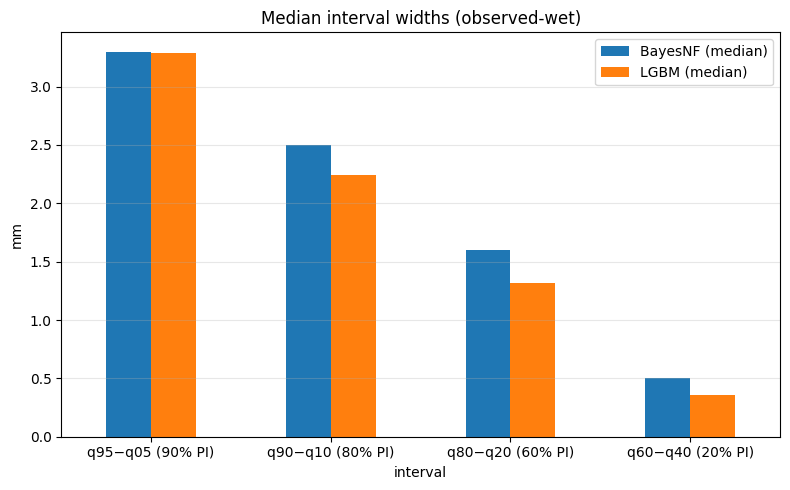

In [8]:
widths = [
    ('q95_minus_q05', 'q95−q05 (90% PI)'),
    ('q90_minus_q10', 'q90−q10 (80% PI)'),
    ('q80_minus_q20', 'q80−q20 (60% PI)'),
    ('q60_minus_q40', 'q60−q40 (20% PI)'),
]
rows = []
for key, nice in widths:
    rows.append({
        'interval': nice,
        'BayesNF (median)': R_bnf['sharpness']['wet'][key]['median'],
        'LGBM (median)':    R_lgbm['sharpness']['wet'][key]['median'],
        'BayesNF (mean)':   R_bnf['sharpness']['wet'][key]['mean'],
        'LGBM (mean)':      R_lgbm['sharpness']['wet'][key]['mean'],
    })
s_df = pd.DataFrame(rows).set_index('interval')
display(s_df.round(3))

ax = s_df[['BayesNF (median)', 'LGBM (median)']].plot.bar(figsize=(8, 5), rot=0)
ax.set_title('Median interval widths (observed-wet)')
ax.set_ylabel('mm')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 9. Spread–skill diagrams

For each row we bin by the predicted spread (e.g., q95−q05) and report
the empirical RMSE in that bin. A useful forecast has RMSE growing with
spread — i.e., when the model says it's uncertain, it actually is.

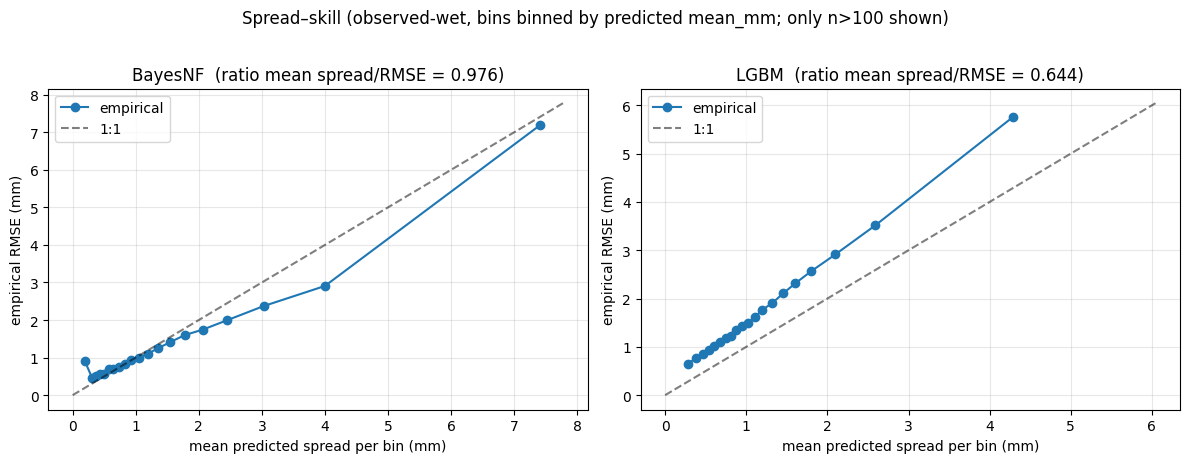

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for a, (lbl, R) in zip(ax, [('BayesNF', R_bnf), ('LGBM', R_lgbm)]):
    ss     = R['spread_skill']
    spread = np.array(ss['spread_per_bin'])
    rmse   = np.array(ss['rmse_per_bin'])
    n      = np.array(ss['n_per_bin'])
    mask   = n > 100
    a.plot(spread[mask], rmse[mask], 'o-', label='empirical')
    lim = max(spread[mask].max(), rmse[mask].max()) * 1.05
    a.plot([0, lim], [0, lim], 'k--', alpha=0.5, label='1:1')
    a.set_title(f'{lbl}  (ratio mean spread/RMSE = {ss["ratio_mean"]:.3f})')
    a.set_xlabel('mean predicted spread per bin (mm)')
    a.set_ylabel('empirical RMSE (mm)')
    a.legend(); a.grid(alpha=0.3)
plt.suptitle('Spread–skill (observed-wet, bins binned by predicted mean_mm; only n>100 shown)', y=1.02)
plt.tight_layout(); plt.show()

## 10. Conditional CRPS by intensity bin

The single CRPS number averages a huge dynamic range — most observations
are in the 0.5–5 mm bin where both models are easy, and a tiny tail of
heavy events dominates the absolute error. The conditional view shows
where each model wins.

model,BayesNF,LGBM,BayesNF (n),LGBM (n)
bin,,,,
0.5–5 mm,0.381,0.492,371656,2416541
5–20 mm,1.125,1.265,143942,1007864
20–50 mm,3.354,3.661,14565,91874
>50 mm,11.890,11.199,853,4548


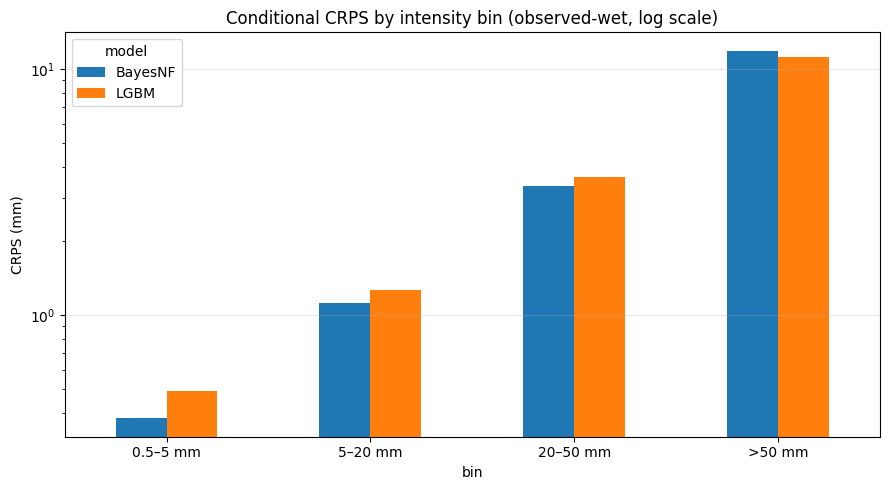

In [10]:
def cc_to_df(R, label):
    rows = []
    for b in R['conditional_crps']['per_bin']:
        if 'dry' in b['name']: continue  # wet-slice only
        rows.append({'bin': b['name'], 'n': b['n'], 'CRPS': b['crps_mean'], 'y_mean': b['y_mean'], 'model': label})
    return pd.DataFrame(rows)

cc_bnf  = cc_to_df(R_bnf,  'BayesNF')
cc_lgbm = cc_to_df(R_lgbm, 'LGBM')

# Align bins
order = ['0.5–5 mm', '5–20 mm', '20–50 mm', '>50 mm']
piv = (pd.concat([cc_bnf, cc_lgbm])
         .pivot(index='bin', columns='model', values='CRPS')
         .reindex(order))
n_tbl = (pd.concat([cc_bnf, cc_lgbm])
           .pivot(index='bin', columns='model', values='n')
           .reindex(order)
           .add_suffix(' (n)'))

display(pd.concat([piv.round(3), n_tbl], axis=1))

ax = piv.plot.bar(figsize=(9, 5), rot=0, logy=True)
ax.set_title('Conditional CRPS by intensity bin (observed-wet, log scale)')
ax.set_ylabel('CRPS (mm)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 11. Hersbach decomposition: CRPS = REL + CRPS_pot + Tail

- **REL** (Reliability): the cost of being mis-calibrated. Zero if the
  forecast is perfectly reliable, regardless of accuracy.
- **CRPS_pot** (Potential CRPS): the CRPS the model would achieve if it
  were *re-calibrated* to its empirical reliability curve. This is the
  irreducible component — how well the forecast places its probability
  mass when given the benefit of perfect calibration.
- **Tail**: outer-bin contribution beyond the 5–95 % quantile range.

,REL,CRPS_pot,Tail,CRPS (sum),CRPS (direct)
model,,,,,
BayesNF,0.0602,0.5418,0.0806,0.6827,0.6827
LGBM,0.0084,0.6728,0.1289,0.8101,0.8101


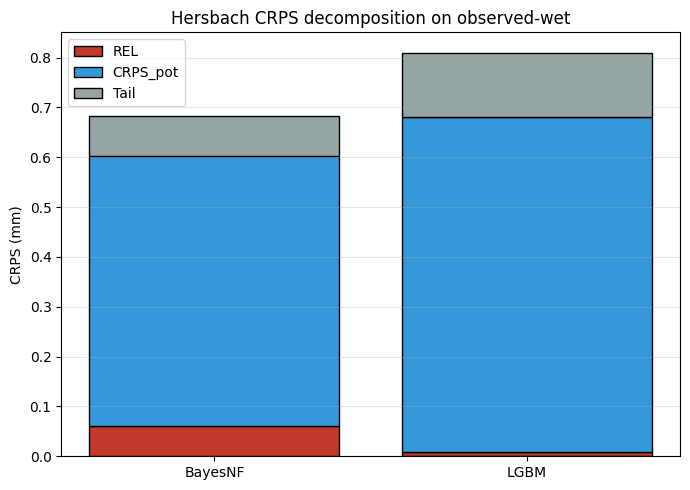

In [11]:
rows = []
for lbl, R in [('BayesNF', R_bnf), ('LGBM', R_lgbm)]:
    h = R['hersbach']
    rows.append({'model': lbl,
                 'REL': h['reliability'],
                 'CRPS_pot': h['crps_pot'],
                 'Tail': h['tail_mean'],
                 'CRPS (sum)': h['reliability'] + h['crps_pot'] + h['tail_mean'],
                 'CRPS (direct)': h['crps_per_row_mean']})
h_df = pd.DataFrame(rows).set_index('model')
display(h_df.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['BayesNF', 'LGBM']
parts  = ['REL', 'CRPS_pot', 'Tail']
bottoms = np.zeros(2)
colors = ['#c0392b', '#3498db', '#95a5a6']
for part, color in zip(parts, colors):
    vals = h_df.loc[labels, part].to_numpy()
    ax.bar(labels, vals, bottom=bottoms, color=color, label=part, edgecolor='k')
    bottoms = bottoms + vals
ax.set_ylabel('CRPS (mm)')
ax.set_title('Hersbach CRPS decomposition on observed-wet')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 12. Interpretation — one paragraph

Read the headline table together with the Hersbach bars:

- If **LGBM's REL ≪ BayesNF's REL** but **CRPS_pot ≫ BayesNF's** — that's
  the classic pattern. Pinball-loss optimises each quantile's marginal
  reliability; BayesNF optimises the joint likelihood, which positions the
  centre of the predictive distribution better. CRPS rewards positioning
  more than marginal calibration, so BayesNF wins on the sum even though
  it loses on REL alone.
- If **sharpness is roughly equal** — neither model is buying its CRPS
  win by being more confident; the win comes from *where* the quantiles
  are, not *how narrow* they are.
- The **conditional CRPS bars** tell you which intensity regime the
  difference lives in. A win concentrated in the >20 mm bins means the
  better model is handling the right tail better; a win in the 0.5–5 mm
  bin means the bulk-precipitation forecast is more accurate.

## 13. Save artifacts

In [12]:
def strip_arrays(R):
    out = {}
    for k, v in R.items():
        if k.startswith('_'): continue
        out[k] = v
    return out

artefact = {
    'scope':       'fold-0 holdout (394 stations), observed-wet (y ≥ 0.5)',
    'caveat':      'time spans differ (BayesNF ≈ 10y, LGBM full record). LGBM OOF is wet-only.',
    'n_stations':  len(fold0_sids),
    'BayesNF':     strip_arrays(R_bnf),
    'LGBM':        strip_arrays(R_lgbm),
    'headline':    tbl.to_dict(),
}

out_dir  = PROJECT_ROOT / 'results' / 'comparison'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'fold0_uncertainty.json'
out_path.write_text(json.dumps(artefact, indent=2, default=str))
print(f'saved: {out_path}  ({out_path.stat().st_size / 1024:.1f} KB)')

# Also push to S3 for thesis-side reuse
s3.upload_file(str(out_path), S3_BUCKET, 'comparison/fold0_uncertainty.json')
print(f'uploaded: s3://{S3_BUCKET}/comparison/fold0_uncertainty.json')

saved: /Users/etomengoi/Desktop/precip_interpolation_thesis/results/comparison/fold0_uncertainty.json  (26.7 KB)


uploaded: s3://thesis-data-ismaktam/comparison/fold0_uncertainty.json
